# 01 — Analyse Exploratoire des Données (EDA)
## Prédiction de la Réadmission Hospitalière chez les Patients Diabétiques

**Dataset :** Diabetes 130-US Hospitals (1999–2008)  
**Cible :** Prédire si un patient diabétique sera réadmis dans les 30 jours suivant sa sortie  
**Type de problème :** Classification Binaire Supervisée

---
### Objectifs du Notebook
1. Comprendre la structure et les métadonnées du dataset
2. Analyser la distribution de la variable cible
3. Détecter les valeurs manquantes et les outliers
4. Explorer les distributions des variables numériques et catégorielles
5. Analyser les corrélations avec la cible
6. Formuler les décisions de prétraitement

## 1. Imports & Configuration

In [1]:
# ─────────────────────────────────────────────────────────────
# Importation des bibliothèques nécessaires
# pandas       → manipulation des données tabulaires
# numpy        → calculs numériques
# matplotlib   → graphiques de base
# seaborn      → graphiques statistiques avancés
# scipy.stats  → tests statistiques (t-test, chi2)
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration globale du style des graphiques
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.size':        10
})

# Palette de couleurs cohérente pour tous les graphiques
BLUE   = '#2E86AB'   # classe majoritaire / neutre
RED    = '#E84855'   # classe minoritaire / alerte
GREEN  = '#2ECC71'   # faible risque
ORANGE = '#F39C12'   # risque modéré

print('✓ Bibliothèques chargées avec succès')

✓ Bibliothèques chargées avec succès


## 2. Chargement des Données

In [2]:
# Chargement du fichier CSV
# na_values='?' : dans ce dataset, les valeurs manquantes sont
# codées avec le caractère '?' — on les convertit en NaN pandas
# pour pouvoir les traiter avec les outils standards
df = pd.read_csv('diabetic_data.csv', na_values='?')

print(f'Dimensions         : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')
print(f'Lignes dupliquées  : {df.duplicated().sum()}')
print(f'Valeurs manquantes : {df.isna().sum().sum():,} (total)')

# Afficher les 5 premières lignes pour vérification visuelle
df.head()

Dimensions         : 101,766 lignes × 50 colonnes
Lignes dupliquées  : 0
Valeurs manquantes : 374,017 (total)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 3. Vue d'Ensemble du Dataset

In [3]:
# Tableau récapitulatif pour chaque colonne :
#   dtype    → type de la variable (int64, object, float64...)
#   missing  → nombre absolu de valeurs manquantes
#   miss_%   → pourcentage de valeurs manquantes
#   nunique  → nombre de valeurs distinctes
# Ce tableau aide à identifier rapidement les colonnes
# problématiques (trop de NaN, trop de modalités...)
overview = pd.DataFrame({
    'dtype':   df.dtypes,
    'missing': df.isna().sum(),
    'miss_%':  (df.isna().mean() * 100).round(2),
    'nunique': df.nunique(),
})
print(overview.to_string())

                           dtype  missing  miss_%  nunique
encounter_id               int64        0    0.00   101766
patient_nbr                int64        0    0.00    71518
race                      object     2273    2.23        5
gender                    object        0    0.00        3
age                       object        0    0.00       10
weight                    object    98569   96.86        9
admission_type_id          int64        0    0.00        8
discharge_disposition_id   int64        0    0.00       26
admission_source_id        int64        0    0.00       17
time_in_hospital           int64        0    0.00       14
payer_code                object    40256   39.56       17
medical_specialty         object    49949   49.08       72
num_lab_procedures         int64        0    0.00      118
num_procedures             int64        0    0.00        7
num_medications            int64        0    0.00       75
number_outpatient          int64        0    0.00       

In [4]:
# Statistiques descriptives des variables numériques
# Indicateurs : count, mean, std, min, 25%, 50%, 75%, max
# Objectif : identifier les distributions asymétriques,
# les valeurs extrêmes potentielles, et l'échelle des variables
num_cols = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures',
    'num_medications',  'number_diagnoses',
    'number_outpatient','number_emergency',   'number_inpatient'
]
df[num_cols].describe().round(2)

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_diagnoses,number_outpatient,number_emergency,number_inpatient
count,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00,101766.00
mean,4.40,43.10,1.34,16.02,7.42,0.37,0.20,0.64
std,2.99,19.67,1.71,8.13,1.93,1.27,0.93,1.26
min,1.00,1.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,2.00,31.00,0.00,10.00,6.00,0.00,0.00,0.00
50%,4.00,44.00,1.00,15.00,8.00,0.00,0.00,0.00
75%,6.00,57.00,2.00,20.00,9.00,0.00,0.00,1.00
max,14.00,132.00,6.00,81.00,16.00,42.00,76.00,21.00


## 4. Analyse de la Variable Cible

Distribution originale (3 classes) :
readmitted
NO     54864
>30    35545
<30    11357

Cible binaire (0 / 1) :
readmitted_30
0    90409
1    11357

Taux de classe positive (<30j) : 11.2%
⚠ Déséquilibre de classes détecté — SMOTE sera appliqué lors du prétraitement


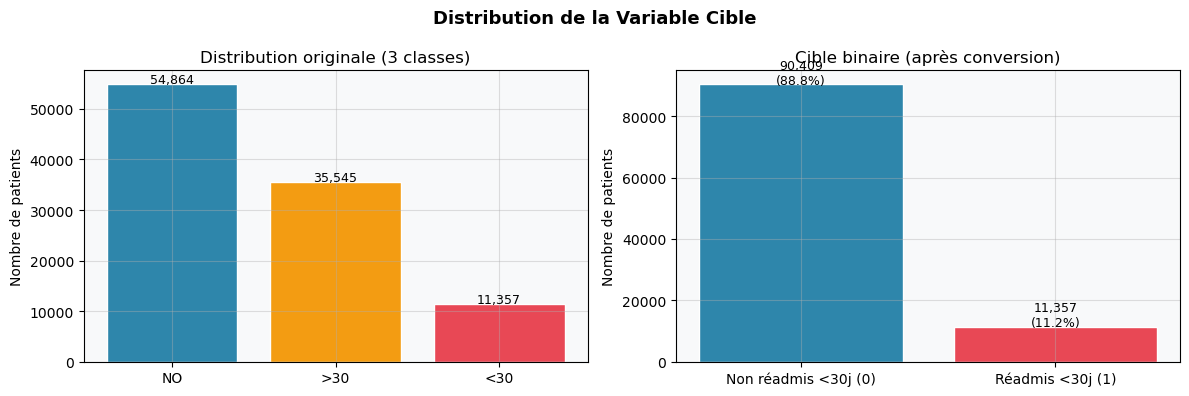

In [5]:
# La variable cible originale 'readmitted' a 3 classes :
#   '<30' → réadmis dans les 30 jours  (cible positive)
#   '>30' → réadmis après 30 jours
#   'NO'  → jamais réadmis
#
# Conversion en variable BINAIRE :
#   1 → réadmis dans les 30 jours  (cas cliniquement urgent)
#   0 → tous les autres cas
#
# Justification : l'objectif business est de détecter
# les réadmissions précoces (<30j) pour intervenir à temps.
# Une réadmission après 30j ou jamais est traitée comme
# un résultat acceptable.
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print('Distribution originale (3 classes) :')
print(df['readmitted'].value_counts().to_string())
print(f'\nCible binaire (0 / 1) :')
print(df['readmitted_30'].value_counts().to_string())
print(f'\nTaux de classe positive (<30j) : {df["readmitted_30"].mean()*100:.1f}%')
print('⚠ Déséquilibre de classes détecté — SMOTE sera appliqué lors du prétraitement')

# Visualisation des deux distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribution de la Variable Cible', fontsize=13, fontweight='bold')

# Graphique 1 : distribution originale à 3 classes
vc = df['readmitted'].value_counts()
bars = axes[0].bar(vc.index, vc.values, color=[BLUE, ORANGE, RED], edgecolor='white')
axes[0].set_title('Distribution originale (3 classes)')
axes[0].set_ylabel('Nombre de patients')
for b in bars:
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{b.get_height():,}', ha='center', fontsize=9)

# Graphique 2 : cible binaire après conversion
vc2 = df['readmitted_30'].value_counts().sort_index()
bars2 = axes[1].bar(['Non réadmis <30j (0)', 'Réadmis <30j (1)'],
                     vc2.values, color=[BLUE, RED], edgecolor='white')
axes[1].set_title('Cible binaire (après conversion)')
axes[1].set_ylabel('Nombre de patients')
for b in bars2:
    axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{b.get_height():,}\n({b.get_height()/len(df)*100:.1f}%)',
                 ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Analyse des Valeurs Manquantes

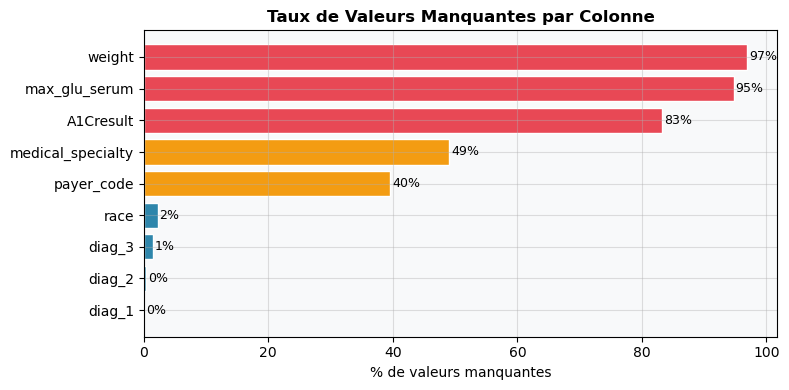

Décisions de traitement :
  weight            (97%) → SUPPRIMER — trop peu de données utilisables
  medical_specialty (53%) → SUPPRIMER — trop peu + colonne administrative
  payer_code        (52%) → SUPPRIMER — trop peu + colonne administrative
  race               (2%) → IMPUTER avec "Unknown" (catégorie cliniquement valide)


In [7]:
# Calcul et visualisation du taux de valeurs manquantes
# Règle de décision :
#   > 50% manquant → supprimer la colonne (trop peu d'info utile)
#   20-50% manquant → supprimer si non critique
#   2-20%  manquant → imputer (médiane pour numérique,
#                               mode pour catégorielle)
miss = df.isna().mean() * 100
miss = miss[miss > 0].sort_values(ascending=False)

# Code couleur selon la sévérité du manque
colors = [RED if v > 50 else ORANGE if v > 20 else BLUE for v in miss.values]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(miss.index, miss.values, color=colors, edgecolor='white')
ax.set_xlabel('% de valeurs manquantes')
ax.set_title('Taux de Valeurs Manquantes par Colonne', fontweight='bold')
ax.invert_yaxis()
# Afficher le pourcentage exact sur chaque barre
for bar, val in zip(bars, miss.values):
    ax.text(val+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.0f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Décisions de traitement :')
print('  weight            (97%) → SUPPRIMER — trop peu de données utilisables')
print('  medical_specialty (53%) → SUPPRIMER — trop peu + colonne administrative')
print('  payer_code        (52%) → SUPPRIMER — trop peu + colonne administrative')
print('  race               (2%) → IMPUTER avec "Unknown" (catégorie cliniquement valide)')

## 6. Détection des Valeurs Aberrantes (Méthode IQR)

           Feature  N outliers  % outliers  Borne inf  Borne sup
 number_outpatient       16739       16.45        0.0        0.0
  number_emergency       11383       11.19        0.0        0.0
  number_inpatient        7049        6.93       -1.5        2.5
    num_procedures        4954        4.87       -3.0        5.0
   num_medications        2557        2.51       -5.0       35.0
  time_in_hospital        2252        2.21       -4.0       12.0
  number_diagnoses         281        0.28        1.5       13.5
num_lab_procedures         143        0.14       -8.0       96.0


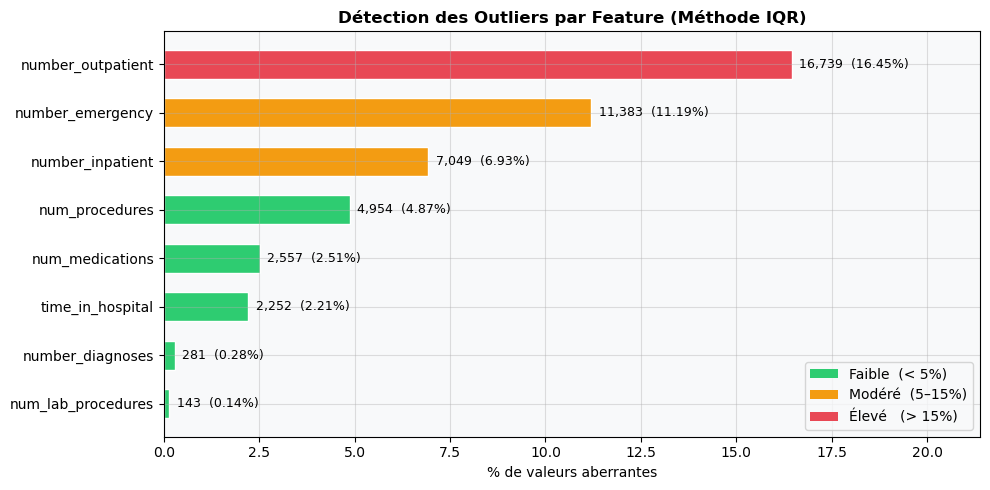

In [8]:
# Méthode IQR (Inter-Quartile Range) :
#   Q1  = 1er quartile (25% des données en dessous)
#   Q3  = 3ème quartile (75% des données en dessous)
#   IQR = Q3 - Q1 (étendue inter-quartile)
#
#   Borne inférieure = Q1 - 1.5 * IQR
#   Borne supérieure = Q3 + 1.5 * IQR
#
#   Toute valeur hors de cet intervalle est considérée
#   comme aberrante (c'est la règle des boîtes à moustaches)
def count_outliers_iqr(series):
    """Compte les outliers selon la règle 1.5×IQR."""
    Q1     = series.quantile(0.25)
    Q3     = series.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - 1.5 * IQR   # borne inférieure
    upper  = Q3 + 1.5 * IQR   # borne supérieure
    n_out  = ((series < lower) | (series > upper)).sum()
    return n_out, lower, upper

# Appliquer sur toutes les colonnes numériques
outlier_report = []
for col in num_cols:
    n_out, lo, hi = count_outliers_iqr(df[col].dropna())
    outlier_report.append({
        'Feature':    col,
        'N outliers': n_out,
        '% outliers': round(n_out / len(df) * 100, 2),
        'Borne inf':  round(lo, 2),
        'Borne sup':  round(hi, 2)
    })

outlier_df = pd.DataFrame(outlier_report).sort_values('N outliers', ascending=False)
print(outlier_df.to_string(index=False))

# Graphique à barres horizontales — code couleur par sévérité
fig, ax = plt.subplots(figsize=(10, 5))
colors  = [RED if p > 15 else ORANGE if p > 5 else GREEN
           for p in outlier_df['% outliers']]
bars    = ax.barh(outlier_df['Feature'], outlier_df['% outliers'],
                  color=colors, edgecolor='white', height=0.6)
ax.set_xlabel('% de valeurs aberrantes')
ax.set_title('Détection des Outliers par Feature (Méthode IQR)', fontweight='bold')
ax.invert_yaxis()
ax.set_xlim(0, outlier_df['% outliers'].max() * 1.3)
# Afficher le nombre et le % sur chaque barre
for bar, pct, n in zip(bars, outlier_df['% outliers'], outlier_df['N outliers']):
    ax.text(bar.get_width()+0.2, bar.get_y()+bar.get_height()/2,
            f'{n:,}  ({pct}%)', va='center', fontsize=9)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor=GREEN,  label='Faible  (< 5%)'),
    Patch(facecolor=ORANGE, label='Modéré  (5–15%)'),
    Patch(facecolor=RED,    label='Élevé   (> 15%)'),
], loc='lower right')
plt.tight_layout()
plt.show()

## 7. Distributions des Variables Numériques

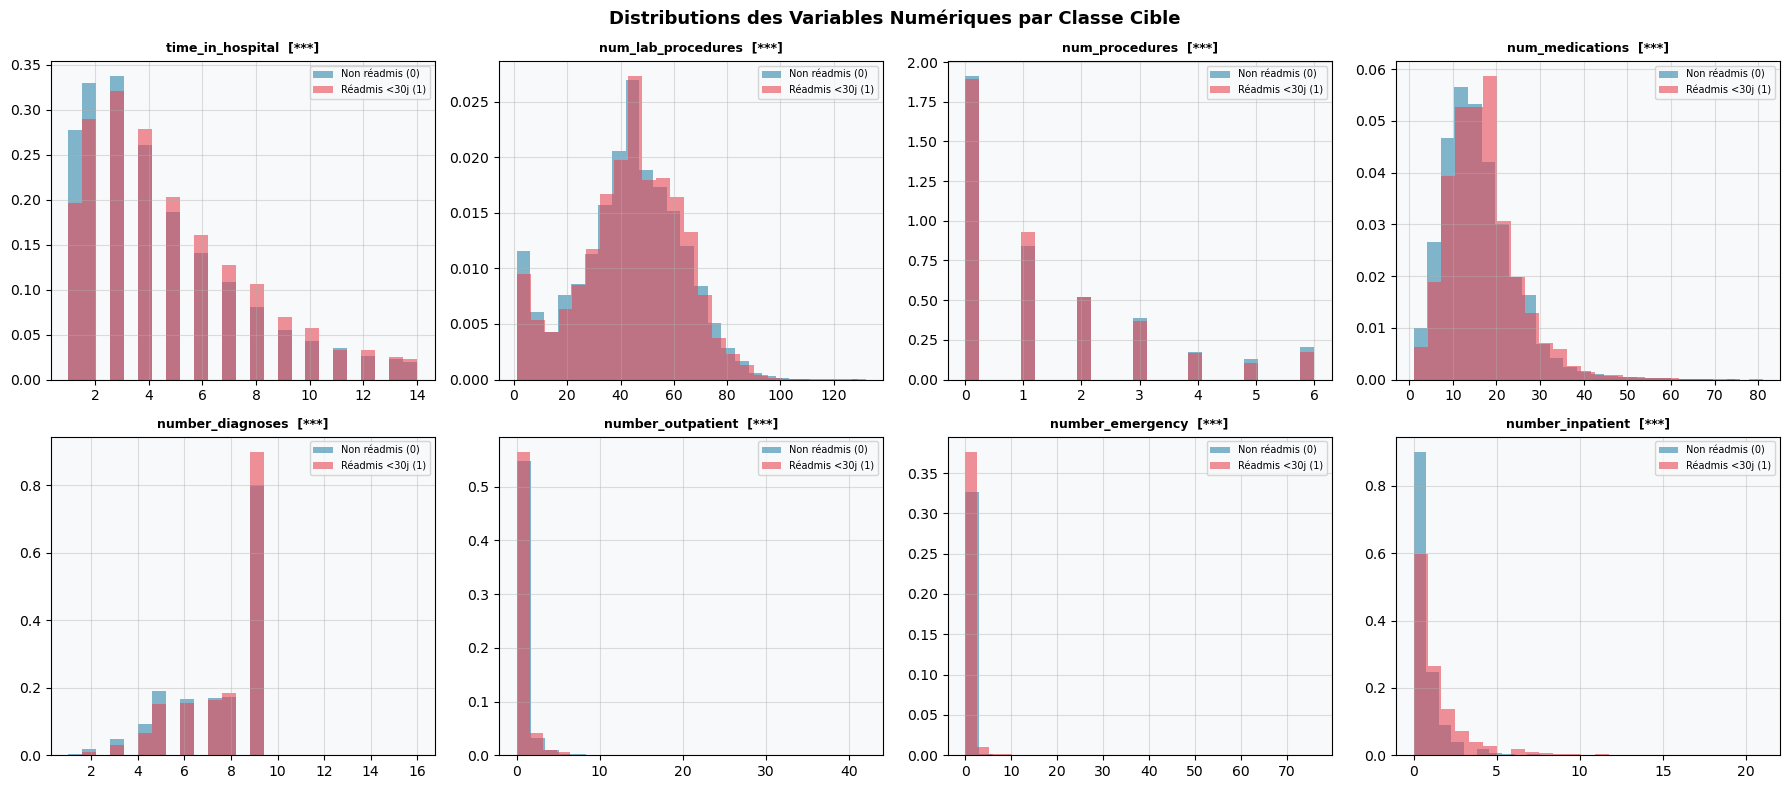

Légende : *** p<0.001 | ** p<0.01 | * p<0.05 | ns = non significatif


In [9]:
# Pour chaque variable numérique, on compare la distribution
# entre les deux classes cibles (0 = non réadmis, 1 = réadmis)
#
# Test statistique : t-test de Welch (Student)
#   Ne suppose pas l'égalité des variances entre les groupes
#   H0 : pas de différence de moyenne entre les deux classes
#   Si p < 0.05 → on rejette H0 → la feature est discriminante
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distributions des Variables Numériques par Classe Cible',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, num_cols):
    # Séparer les deux groupes
    d0 = df.loc[df['readmitted_30'] == 0, col].dropna()
    d1 = df.loc[df['readmitted_30'] == 1, col].dropna()

    # Histogrammes superposés avec normalisation (density=True)
    ax.hist(d0, bins=25, alpha=0.6, color=BLUE, label='Non réadmis (0)', density=True)
    ax.hist(d1, bins=25, alpha=0.6, color=RED,  label='Réadmis <30j (1)', density=True)

    # Test t de Welch pour évaluer la significativité statistique
    _, p = stats.ttest_ind(d0, d1, equal_var=False)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    ax.set_title(f'{col}  [{sig}]', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()
print('Légende : *** p<0.001 | ** p<0.01 | * p<0.05 | ns = non significatif')

## 8. Analyse des Variables Catégorielles

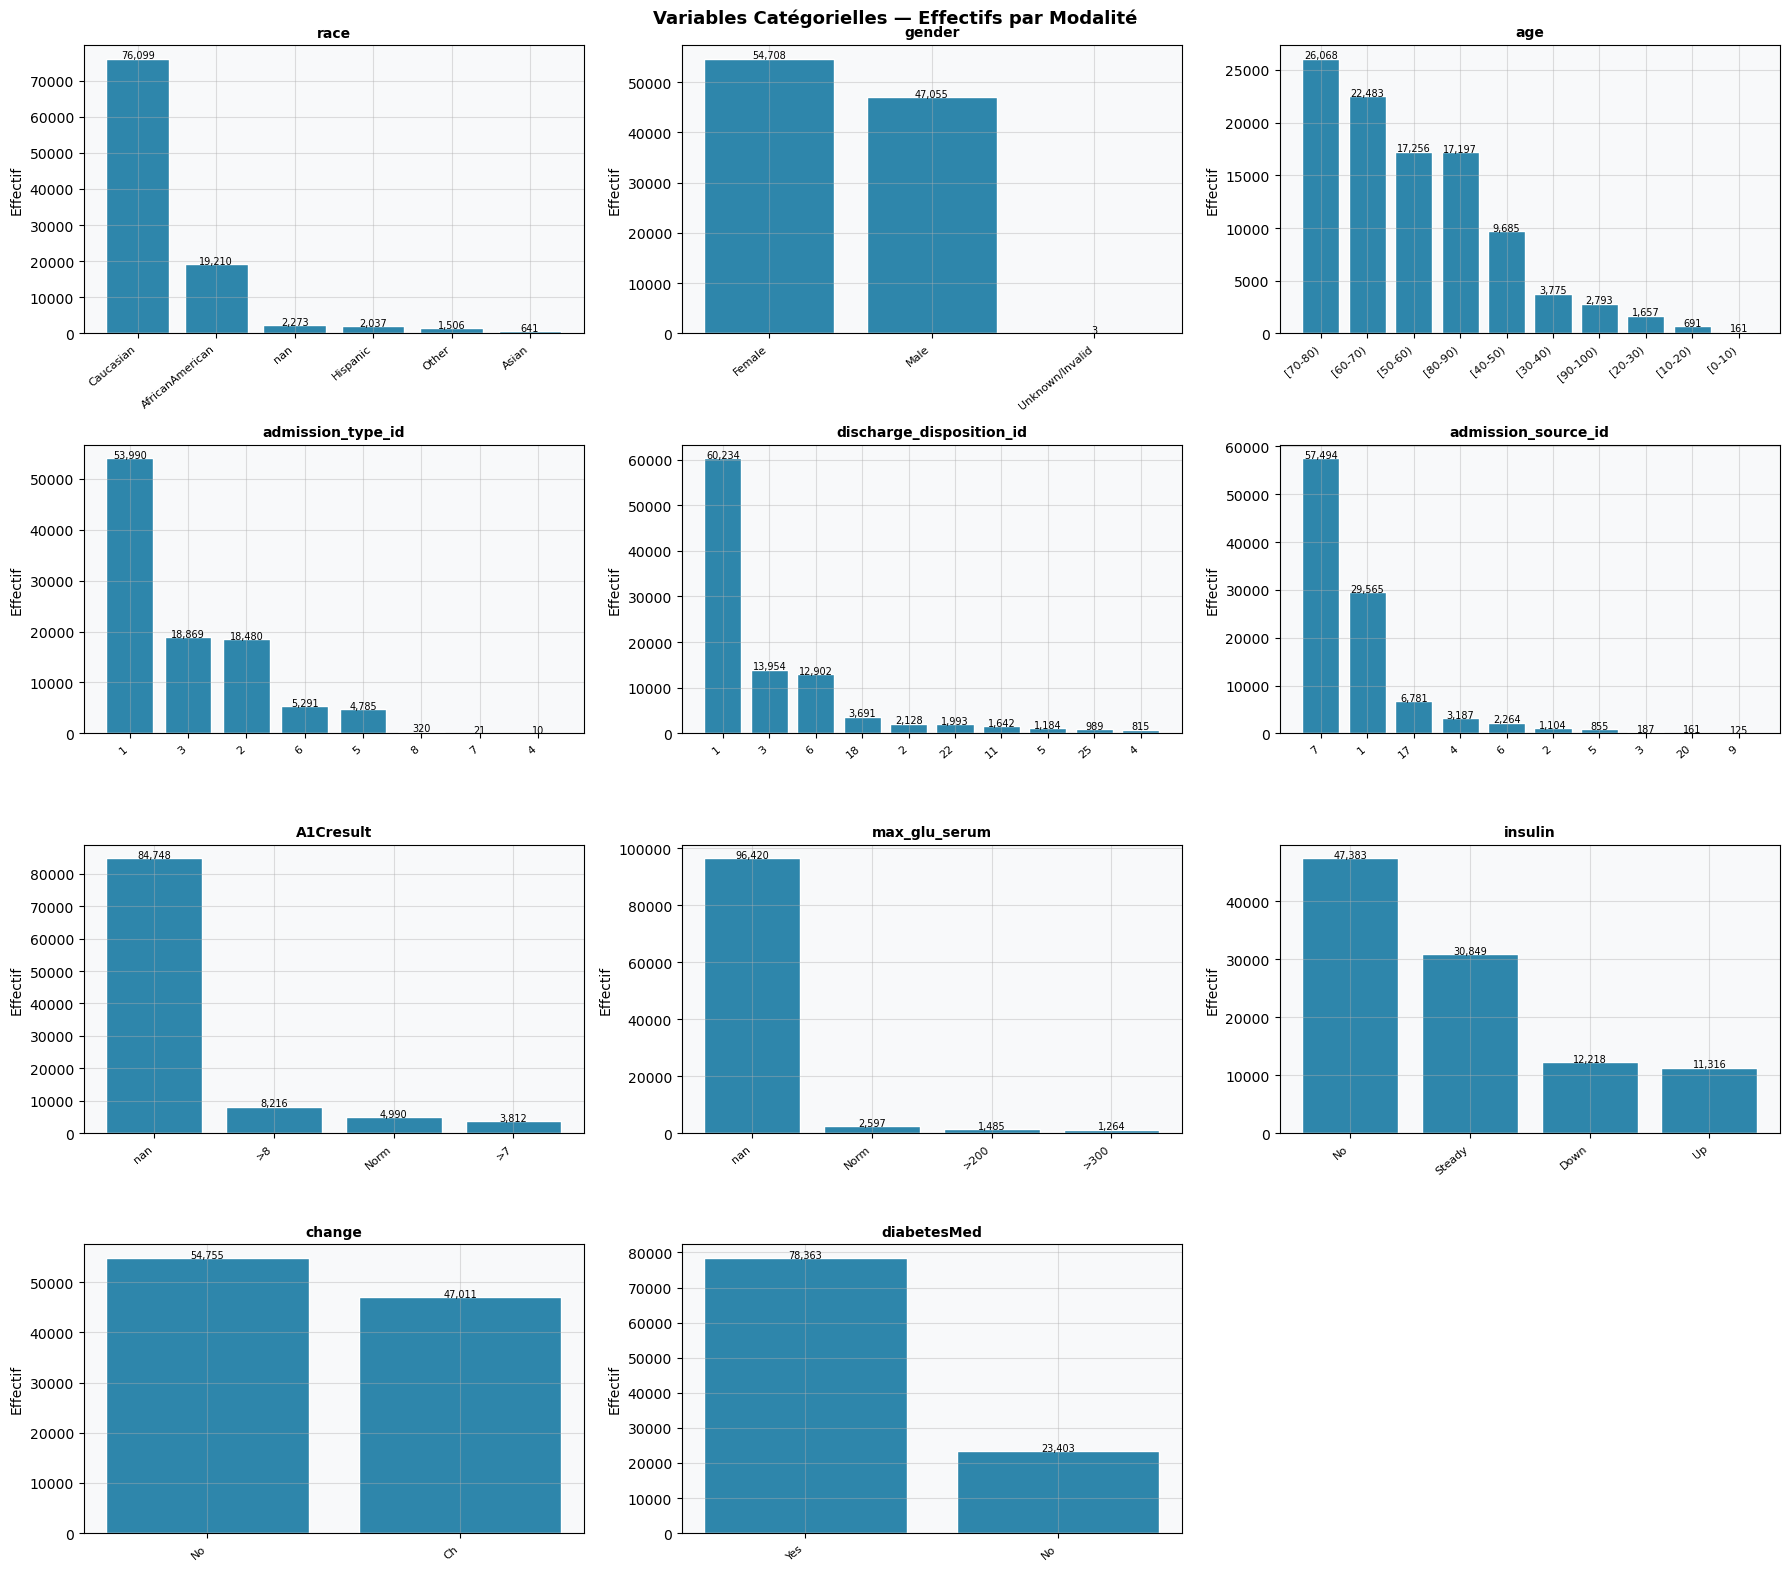

In [10]:
# ─────────────────────────────────────────────────────────────
# Variables catégorielles sélectionnées pour l'analyse :
#   - Variables démographiques : race, gender, age
#   - Variables administratives : admission_type, discharge, source
#   - Variables cliniques : A1Cresult, max_glu_serum, insulin
#   - Variables médicaments : change, diabetesMed
#
# On exclut diag_1/2/3 car ils ont 800+ modalités
# → ils seront groupés via ICD-9 dans le preprocessing
# ─────────────────────────────────────────────────────────────
cat_features = [
    'race', 'gender', 'age', 'admission_type_id',
    'discharge_disposition_id', 'admission_source_id',
    'A1Cresult', 'max_glu_serum', 'insulin', 'change', 'diabetesMed'
]
cat_features = [c for c in cat_features if c in df.columns]

n     = len(cat_features)
ncols = 3
nrows = (n + ncols - 1) // ncols

# ── Figure 1 : Effectifs par modalité ──────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle('Variables Catégorielles — Effectifs par Modalité',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, cat_features):
    # On prend les 10 modalités les plus fréquentes
    vc = df[col].astype(str).value_counts().head(10)
    ax.bar(range(len(vc)), vc.values, color=BLUE, edgecolor='white')
    ax.set_xticks(range(len(vc)))
    ax.set_xticklabels(vc.index, rotation=40, ha='right', fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Effectif')
    # Annoter chaque barre
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                f'{int(bar.get_height()):,}', ha='center', fontsize=7)

# Masquer les sous-graphiques inutilisés
for ax in list(axes.flat)[len(cat_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

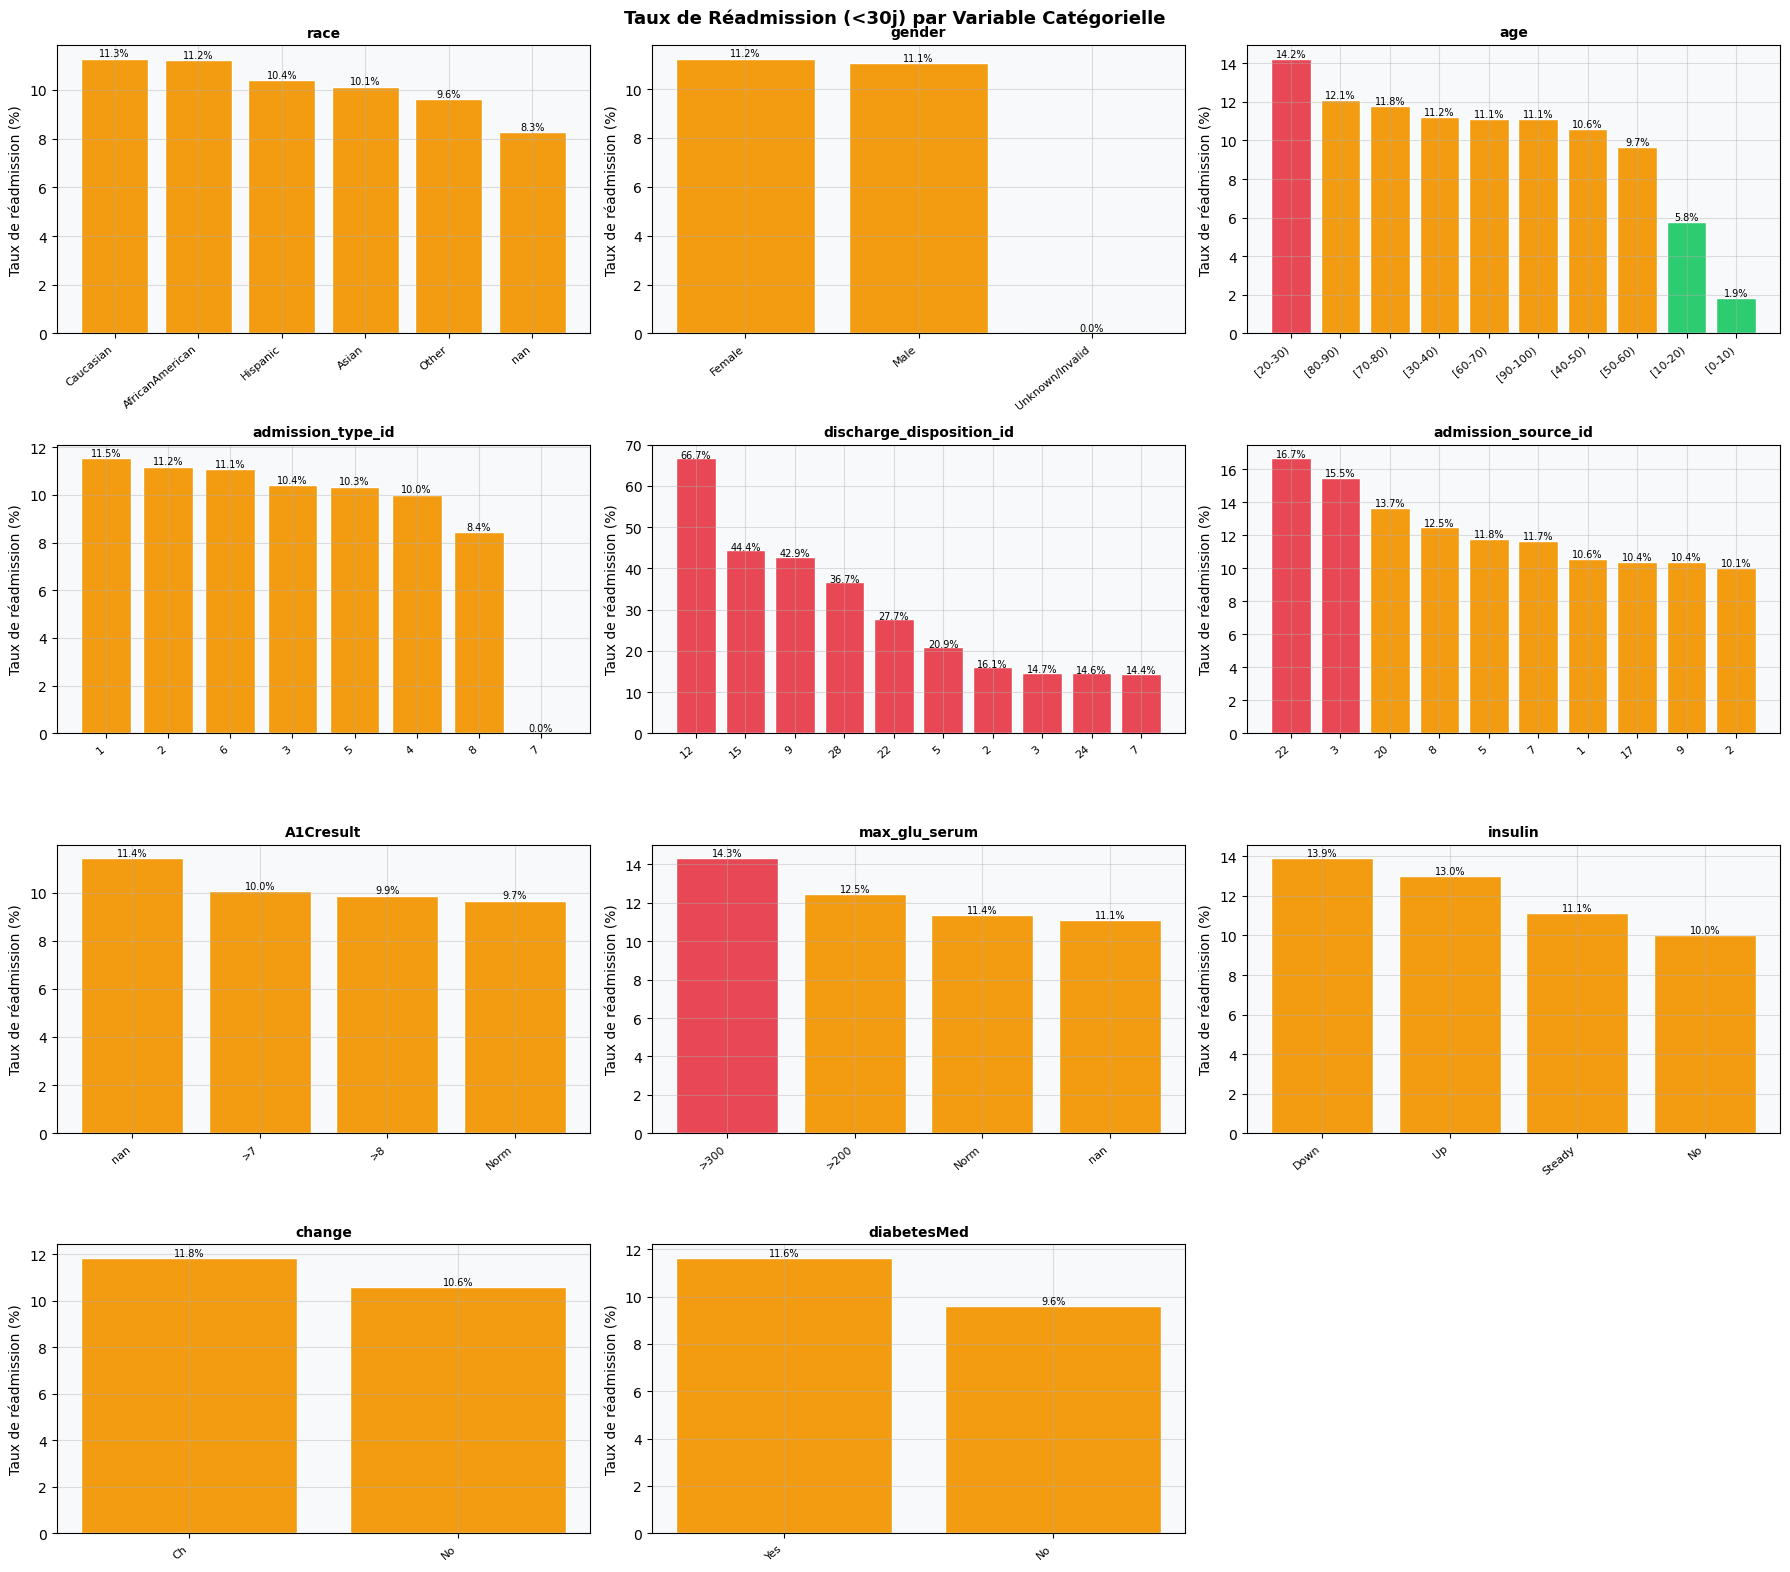

In [11]:
# ─────────────────────────────────────────────────────────────
# Figure 2 : Taux de réadmission par modalité
# Pour chaque modalité, on calcule la proportion de patients
# réadmis dans les 30 jours.
#
# Code couleur :
#   Vert   → taux < 8%  (faible risque)
#   Orange → taux 8–14% (risque modéré)
#   Rouge  → taux > 14% (risque élevé)
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
fig.suptitle('Taux de Réadmission (<30j) par Variable Catégorielle',
             fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, cat_features):
    # Taux moyen de réadmission par modalité, trié décroissant
    rate = (df.groupby(df[col].astype(str))['readmitted_30']
              .mean()
              .sort_values(ascending=False)
              .head(10))

    # Couleur conditionnelle selon le niveau de risque
    bar_colors = [
        RED if v > 0.14 else ORANGE if v > 0.08 else GREEN
        for v in rate.values
    ]

    ax.bar(range(len(rate)), rate.values * 100,
           color=bar_colors, edgecolor='white')
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index, rotation=40, ha='right', fontsize=8)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_ylabel('Taux de réadmission (%)')

    # Annoter chaque barre avec le taux exact
    for bar in ax.patches:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{bar.get_height():.1f}%', ha='center', fontsize=7)

for ax in list(axes.flat)[len(cat_features):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## 9. Corrélation avec la Variable Cible

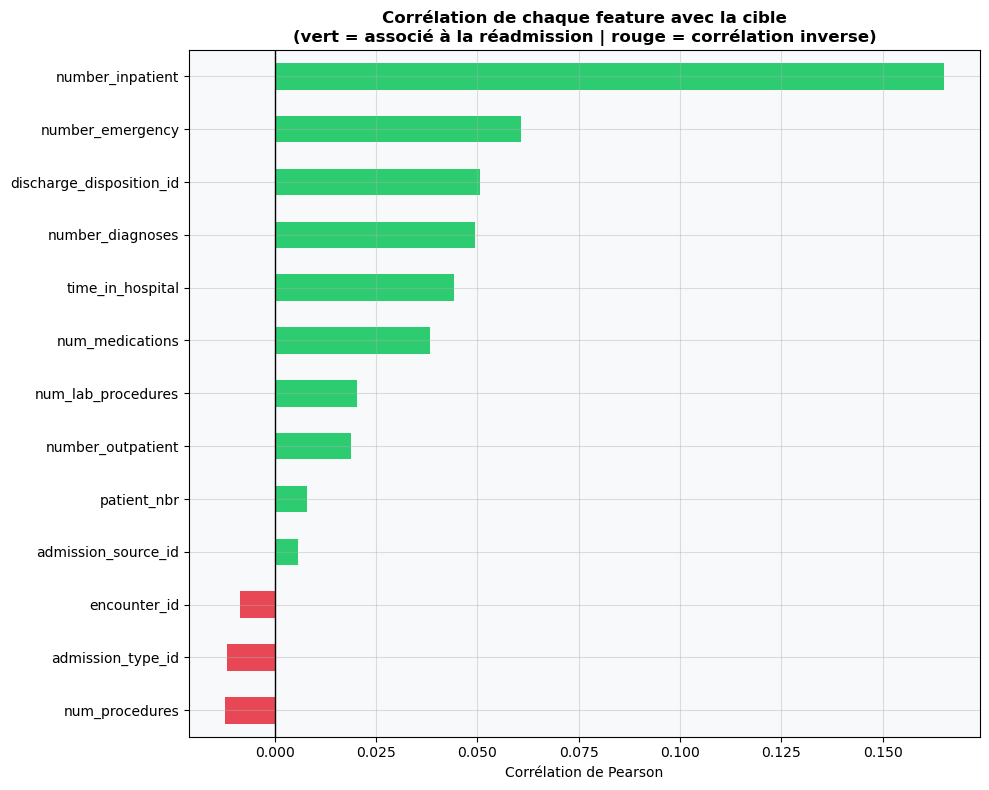

Top 5 features positivement corrélées avec la réadmission (<30j) :
time_in_hospital            0.0442
number_diagnoses            0.0495
discharge_disposition_id    0.0506
number_emergency            0.0607
number_inpatient            0.1651

Top 5 features négativement corrélées avec la réadmission :
num_procedures        -0.0122
admission_type_id     -0.0117
encounter_id          -0.0085
admission_source_id    0.0058
patient_nbr            0.0079


In [12]:
# ─────────────────────────────────────────────────────────────
# Corrélation de Pearson entre chaque variable numérique
# et la cible binaire readmitted_30
#
# Interprétation :
#   Corrélation positive (vert) → quand la variable augmente,
#     la probabilité de réadmission augmente aussi
#   Corrélation négative (rouge) → quand la variable augmente,
#     la probabilité de réadmission diminue
#
# Note : Pearson mesure les relations LINÉAIRES uniquement.
# Les modèles non-linéaires (RF, GB) peuvent capter davantage.
# ─────────────────────────────────────────────────────────────
df_corr = df.copy()

# Calculer la corrélation uniquement sur les colonnes numériques
corr_with_target = (
    df_corr
    .select_dtypes(include=[np.number])
    .corr()['readmitted_30']
    .drop('readmitted_30')   # exclure la corrélation avec elle-même
    .sort_values()
)

# Code couleur
colors = [RED if x < 0 else GREEN for x in corr_with_target]

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(x=0, color='black', linewidth=1)   # ligne de référence à zéro
ax.set_title(
    'Corrélation de chaque feature avec la cible\n'
    '(vert = associé à la réadmission | rouge = corrélation inverse)',
    fontweight='bold', fontsize=12
)
ax.set_xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.show()

print('Top 5 features positivement corrélées avec la réadmission (<30j) :')
print(corr_with_target.tail(5).round(4).to_string())
print('\nTop 5 features négativement corrélées avec la réadmission :')
print(corr_with_target.head(5).round(4).to_string())

## 10. Résumé EDA — Décisions de Prétraitement

In [13]:
# ─────────────────────────────────────────────────────────────
# Récapitulatif structuré de toutes les décisions prises
# suite à l'analyse exploratoire.
# Ces décisions seront implémentées dans le notebook 02.
# ─────────────────────────────────────────────────────────────
print('=' * 70)
print('RÉSUMÉ EDA — DÉCISIONS DE PRÉTRAITEMENT')
print('=' * 70)

decisions = [
    ('Valeurs manquantes',    'weight(97%), payer_code(52%), medical_specialty(53%) → Supprimer'),
    ('Doublons',              'Vérifiés → Supprimer si présents'),
    ('Déséquilibre classes',  'Sévère (89% vs 11%) → SMOTE sur le train uniquement'),
    ('Outliers',              'number_outpatient, number_emergency → forte asymétrie droite'),
    ('Variables catégorielles','Label encoding (binaire), One-Hot encoding (nominales)'),
    ('Normalisation',         'StandardScaler pour LR (obligatoire), non requis pour arbres'),
    ('Feature Engineering',   '5 nouvelles features : n_active_meds, n_med_changes, prior_visits, age_mid, ICD-9'),
    ('Sélection features',    'Importance Random Forest / Gradient Boosting'),
    ('Métriques',             'F1-score + ROC-AUC + Matrice de confusion'),
]

for i, (aspect, decision) in enumerate(decisions, 1):
    print(f'  {i:2d}. {aspect:<27s} → {decision}')

print('\nFeatures les plus discriminantes identifiées :')
print('   → number_inpatient    (prédicteur le plus fort de réadmission)')
print('   → time_in_hospital    (durée de séjour = indicateur de complexité)')
print('   → num_medications     (nombre de médicaments = complexité du traitement)')
print('   → insulin             (gestion glycémique — indicateur clé du diabète)')
print('   → number_diagnoses    (charge de comorbidités)')

RÉSUMÉ EDA — DÉCISIONS DE PRÉTRAITEMENT
   1. Valeurs manquantes          → weight(97%), payer_code(52%), medical_specialty(53%) → Supprimer
   2. Doublons                    → Vérifiés → Supprimer si présents
   3. Déséquilibre classes        → Sévère (89% vs 11%) → SMOTE sur le train uniquement
   4. Outliers                    → number_outpatient, number_emergency → forte asymétrie droite
   5. Variables catégorielles     → Label encoding (binaire), One-Hot encoding (nominales)
   6. Normalisation               → StandardScaler pour LR (obligatoire), non requis pour arbres
   7. Feature Engineering         → 5 nouvelles features : n_active_meds, n_med_changes, prior_visits, age_mid, ICD-9
   8. Sélection features          → Importance Random Forest / Gradient Boosting
   9. Métriques                   → F1-score + ROC-AUC + Matrice de confusion

Features les plus discriminantes identifiées :
   → number_inpatient    (prédicteur le plus fort de réadmission)
   → time_in_hospital    (